In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns      

In [ ]:
person=pd.read_csv("person_profile.csv")
film=pd.read_csv("film_career.csv")
political=pd.read_csv("political_career.csv")
family=pd.read_csv("family_relations.csv")
popularity=pd.read_csv("popularity_metrics.csv")

In [ ]:
popularity.describe()
film.describe(include='all')

,Year,Movie,Genre,Role,BoxOffice_Status
count,22.000000,22,22,22,22
unique,NaN,22,9,1,4
top,NaN,Akkada Ammayi Ikkada Abbayi,Action,Lead,Hit
freq,NaN,1,7,22,9
mean,2009.227273,NaN,NaN,NaN,NaN
std,9.496525,NaN,NaN,NaN,NaN
min,1996.000000,NaN,NaN,NaN,NaN
25%,2000.250000,NaN,NaN,NaN,NaN
50%,2009.500000,NaN,NaN,NaN,NaN
75%,2016.750000,NaN,NaN,NaN,NaN


In [ ]:
person.info()

<class 'pandas.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Name           1 non-null      str  
 1   Date_of_Birth  1 non-null      str  
 2   Profession     1 non-null      str  
 3   State          1 non-null      str  
dtypes: str(4)
memory usage: 164.0 bytes


In [ ]:
film.info()

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Year              22 non-null     int64
 1   Movie             22 non-null     str  
 2   Genre             22 non-null     str  
 3   Role              22 non-null     str  
 4   BoxOffice_Status  22 non-null     str  
dtypes: int64(1), str(4)
memory usage: 1012.0 bytes


In [ ]:
popularity.info()

<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Year              13 non-null     int64
 1   Popularity_Score  13 non-null     int64
dtypes: int64(2)
memory usage: 340.0 bytes


In [ ]:
person.isnull().sum()

Name             0
Date_of_Birth    0
Profession       0
State            0
dtype: int64

In [ ]:
film.isnull().sum()
popularity.isnull().sum()

Year                0
Popularity_Score    0
dtype: int64

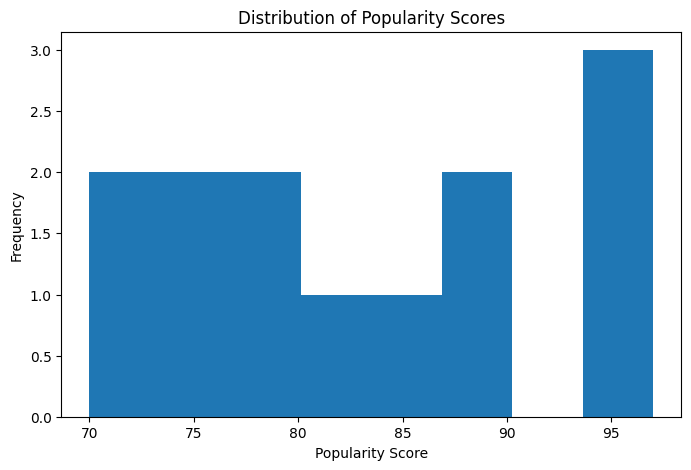

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(
popularity["Popularity_Score"],bins=8)
plt.xlabel("Popularity Score")
plt.ylabel("Frequency")
plt.title("Distribution of Popularity Scores")
plt.show()

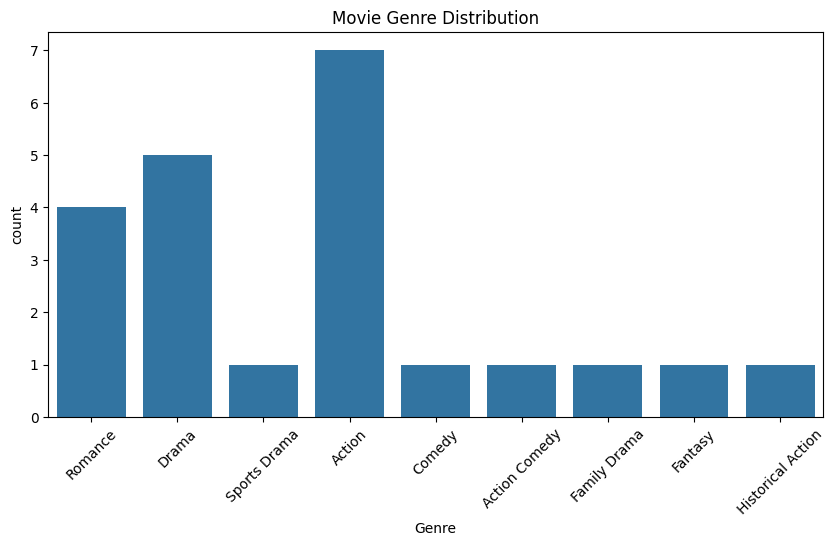

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x=film["Genre"])
plt.xticks(rotation=45)
plt.title("Movie Genre Distribution")
plt.show()

In [ ]:
%load_ext sql

ModuleNotFoundError: No module named 'sql'

In [ ]:
import sqlite3

In [ ]:
conn = sqlite3.connect("pawan_project.db")

print("Database created")

Database created


In [ ]:
person.to_sql("person_profile",conn,if_exists="replace",index=False)

film.to_sql("film_career",conn,if_exists="replace",index=False)

political.to_sql("political_career",conn,if_exists="replace",index=False)

popularity.to_sql("popularity_metrics",conn,if_exists="replace",index=False)

print("Tables created successfully")

Tables created successfully


In [ ]:
query="""
SELECT Year,Popularity_Score
FROM popularity_metrics
ORDER BY Popularity_Score DESC
LIMIT 5
"""

result=pd.read_sql(query,conn)

print(result)

   Year  Popularity_Score
0  2026                97
1  2025                96
2  2024                95
3  2023                90
4  2022                88


In [ ]:
query="""
SELECT Genre,
COUNT(*) AS Total
FROM film_career
GROUP BY Genre
ORDER BY Total DESC
"""

result=pd.read_sql(query,conn)

print(result)

               Genre  Total
0             Action      7
1              Drama      5
2            Romance      4
3       Sports Drama      1
4  Historical Action      1
5            Fantasy      1
6       Family Drama      1
7             Comedy      1
8      Action Comedy      1
